# Step 6. Ablation Study (대안데이터 기여도 정량 검증)

대안데이터가 **실제로** 포트폴리오 성과를 개선하는지, 4가지 설정(Config)을 비교하여 검증합니다.

| Config | 경보 기준 | 설명 |
|--------|----------|------|
| A (Baseline) | VIX >= 20/28/35 | 기존 시스템 |
| B (+기간구조) | VIX + VIX_contango < 0 | 최소 대안데이터 |
| C (+신용/매크로) | 복합 스코어 (7지표, 25/50/75 임계) | Tier 1 전체 |
| D (+디바운싱) | 복합 스코어 + 5일 디바운싱 | 최종 시스템 |

In [1]:
# ============================================================
# 라이브러리 및 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(os.getcwd(), 'data')
IMG_DIR  = os.path.join(os.getcwd(), 'images')

# 기존 프로젝트 시세 데이터
df_prices = pd.read_csv(os.path.join(BASE_DIR, 'prices.csv'), index_col=0, parse_dates=True)

# Step2 확장 회귀 데이터
df_reg = pd.read_csv(os.path.join(DATA_DIR, 'df_reg_v2.csv'), index_col=0, parse_dates=True)

# Step5 경보 데이터
df_alert = pd.read_csv(os.path.join(DATA_DIR, 'alert_signals.csv'), index_col=0, parse_dates=True)

print(f'prices  : {df_prices.shape}')
print(f'df_reg  : {df_reg.shape}')
print(f'alerts  : {df_alert.shape}')

prices  : (1825, 13)
df_reg  : (1045, 34)
alerts  : (1045, 4)


## 6-1. 포트폴리오 수익률 및 경보 시그널 준비

In [2]:
# ============================================================
# 포트폴리오 수익률 계산 (동일 비중 1/6)
# ============================================================

PORT_TICKERS = ['SPY', 'QQQ', 'TLT', 'AGG', 'GLD', 'EEM']
EQUITY = ['SPY', 'QQQ', 'EEM']
BOND   = ['TLT', 'AGG']
GOLD   = ['GLD']

# NYSE 영업일 정렬
nyse = pd.bdate_range('2021-01-01', '2025-12-31', freq='B')
prices = df_prices[PORT_TICKERS].reindex(nyse).ffill().bfill()

# 개별 자산 일별 수익률
asset_ret = prices.pct_change().dropna()

# 공통 날짜 범위 (df_reg와 겹치는 기간)
common_idx = asset_ret.index.intersection(df_reg.index)
asset_ret = asset_ret.loc[common_idx]

print(f'자산 수익률: {asset_ret.shape}')
print(f'기간: {common_idx[0].date()} ~ {common_idx[-1].date()}')

자산 수익률: (1045, 6)
기간: 2021-12-30 ~ 2025-12-31


In [3]:
# ============================================================
# 4가지 Config 경보 시그널 생성
# ============================================================

# ── Config A: VIX-only (기존) ──
vix = df_reg.loc[common_idx, 'VIX_level']
alert_A = (vix >= 20).astype(int) + (vix >= 28).astype(int) + (vix >= 35).astype(int)
alert_A.name = 'A_VIX_only'

# ── Config B: VIX + VIX_contango ──
#    VIX 경보 + 백워데이션 시 1단계 추가
contango = df_reg.loc[common_idx, 'VIX_contango']
backwardation_boost = (contango < 0).astype(int)  # 백워데이션이면 +1
alert_B = np.clip(alert_A + backwardation_boost, 0, 3)
alert_B.name = 'B_VIX_contango'

# ── Config C: 복합 스코어 (디바운싱 전) ──
alert_C = df_alert.loc[common_idx, 'alert_raw']
alert_C.name = 'C_composite_raw'

# ── Config D: 복합 스코어 (디바운싱 후) ──
alert_D = df_alert.loc[common_idx, 'alert_debounced']
alert_D.name = 'D_composite_debounced'

# 경보 분포 요약
alerts_all = pd.DataFrame({'A': alert_A, 'B': alert_B, 'C': alert_C, 'D': alert_D})
print('=== Config별 경보 등급 분포 ===')
for col in ['A', 'B', 'C', 'D']:
    dist = alerts_all[col].value_counts().sort_index()
    print(f'  Config {col}: {dict(dist)}')

=== Config별 경보 등급 분포 ===
  Config A: {0: np.int64(674), 1: np.int64(278), 2: np.int64(85), 3: np.int64(8)}
  Config B: {0: np.int64(674), 1: np.int64(255), 2: np.int64(85), 3: np.int64(31)}
  Config C: {0: np.int64(159), 1: np.int64(859), 2: np.int64(27)}
  Config D: {0: np.int64(197), 1: np.int64(837), 2: np.int64(11)}


## 6-2. 동적 리밸런싱 시뮬레이션

각 Config의 경보 등급에 따라 주식 비중을 조정하고, 포트폴리오 수익률을 산출합니다.

| 경보 등급 | 주식 비중 조정 | 해제된 비중 배분 |
|----------|--------------|---------------|
| 0 (정상) | 유지 (각 1/6) | - |
| 1 (L1) | 주식 -10% | 채권 70% + 금 30% |
| 2 (L2) | 주식 -25% | 채권 70% + 금 30% |
| 3 (L3) | 주식 -50% | 채권 70% + 금 30% |

In [4]:
# ============================================================
# 동적 리밸런싱 시뮬레이션
# ============================================================

# 경보 등급별 주식 축소 비율
EQUITY_CUT = {0: 0.0, 1: 0.10, 2: 0.25, 3: 0.50}

def dynamic_rebalance(alert_series, asset_returns, cost_bps=15):
    """
    경보 시그널 기반 동적 리밸런싱 백테스팅.
    
    Parameters:
        alert_series: 일별 경보 등급 (0~3)
        asset_returns: 6개 자산의 일별 수익률 DataFrame
        cost_bps: 리밸런싱 거래비용 (basis points)
    
    Returns:
        daily_returns: 비용 차감 후 포트폴리오 일별 수익률
    """
    base_w = np.array([1/6] * 6)  # 동일 비중 기본
    prev_w = base_w.copy()
    daily_rets = []
    
    equity_idx = [PORT_TICKERS.index(t) for t in EQUITY]  # SPY, QQQ, EEM
    bond_idx   = [PORT_TICKERS.index(t) for t in BOND]    # TLT, AGG
    gold_idx   = [PORT_TICKERS.index(t) for t in GOLD]    # GLD
    
    for date in asset_returns.index:
        alert_level = alert_series.get(date, 0)
        cut = EQUITY_CUT.get(alert_level, 0)
        
        # 비중 조정
        w = base_w.copy()
        if cut > 0:
            # 주식에서 빼기
            freed = 0
            for idx in equity_idx:
                reduction = w[idx] * cut
                w[idx] -= reduction
                freed += reduction
            # 채권 70% + 금 30%로 재배분
            for idx in bond_idx:
                w[idx] += freed * 0.70 / len(bond_idx)
            for idx in gold_idx:
                w[idx] += freed * 0.30 / len(gold_idx)
        
        # 비중 정규화
        w = np.clip(w, 0, 1)
        w = w / w.sum()
        
        # 거래비용: 비중 변화의 합 x cost_bps
        turnover = np.abs(w - prev_w).sum()
        cost = turnover * cost_bps / 10000
        
        # 포트폴리오 수익률
        ret = (w * asset_returns.loc[date].values).sum() - cost
        daily_rets.append(ret)
        prev_w = w
    
    return pd.Series(daily_rets, index=asset_returns.index, name=alert_series.name)

# 4가지 Config 시뮬레이션
results = {}
for name, alert in [('A_VIX_only', alert_A), ('B_VIX+Contango', alert_B),
                     ('C_Composite', alert_C), ('D_Composite+Debounce', alert_D)]:
    alert.name = name
    results[name] = dynamic_rebalance(alert, asset_ret)
    
# 기준선: 동일 비중 (리밸런싱 없음)
results['Baseline_EW'] = (asset_ret * (1/6)).sum(axis=1)
results['Baseline_EW'].name = 'Baseline_EW'

df_results = pd.DataFrame(results)
print(f'시뮬레이션 완료: {df_results.shape}')
df_results.head(3)

시뮬레이션 완료: (1045, 5)


,A_VIX_only,B_VIX+Contango,C_Composite,D_Composite+Debounce,Baseline_EW
2021-12-30,0.003910,0.003910,0.003910,0.003910,0.003910
2021-12-31,-0.000869,-0.000869,-0.000869,-0.000869,-0.000869
2022-01-03,-0.004315,-0.004315,-0.004315,-0.004315,-0.004315


## 6-3. 성과 메트릭 비교

In [5]:
# ============================================================
# 성과 메트릭 함수
# ============================================================

def compute_metrics(daily_ret):
    """일별 수익률로부터 주요 성과 지표 계산."""
    ann_ret = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    
    # MDD
    cum = (1 + daily_ret).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    mdd = dd.min()
    
    # Calmar
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    
    # CVaR 99%
    var_99 = daily_ret.quantile(0.01)
    cvar_99 = daily_ret[daily_ret <= var_99].mean()
    
    # Sortino
    downside = daily_ret[daily_ret < 0].std() * np.sqrt(252)
    sortino = ann_ret / downside if downside > 0 else 0
    
    return {
        '연율 수익률': f'{ann_ret:.2%}',
        '연율 변동성': f'{ann_vol:.2%}',
        'Sharpe': round(sharpe, 3),
        'Sortino': round(sortino, 3),
        'MDD': f'{mdd:.2%}',
        'Calmar': round(calmar, 3),
        'CVaR 99%': f'{cvar_99:.4f}',
    }

# 전체 Config 메트릭
metrics_list = []
for config_name in df_results.columns:
    m = compute_metrics(df_results[config_name])
    m['Config'] = config_name
    metrics_list.append(m)

df_metrics = pd.DataFrame(metrics_list).set_index('Config')
print('=== Config별 성과 메트릭 비교 ===')
print(df_metrics.to_string())

=== Config별 성과 메트릭 비교 ===
                     연율 수익률  연율 변동성  Sharpe  Sortino      MDD  Calmar CVaR 99%
Config                                                                        
A_VIX_only            9.07%  10.54%   0.861    1.313  -21.72%   0.418  -0.0194
B_VIX+Contango        9.23%  10.39%   0.888    1.351  -21.26%   0.434  -0.0193
C_Composite           7.92%  10.65%   0.744    1.103  -23.43%   0.338  -0.0202
D_Composite+Debounce  7.30%  10.71%   0.682    0.999  -23.84%   0.306  -0.0209
Baseline_EW           7.83%  11.23%   0.697    1.024  -24.09%   0.325  -0.0223


## 6-4. 부트스트랩 Sharpe Ratio 유의성 검정

In [6]:
# ============================================================
# 부트스트랩 Sharpe 차이 검정
# ============================================================

def bootstrap_sharpe_diff(ret_a, ret_b, n_boot=5000, seed=42):
    """
    두 전략의 Sharpe Ratio 차이에 대한 부트스트랩 95% 신뢰구간.
    CI 하한 > 0 이면 ret_b가 통계적으로 유의하게 ret_a보다 우수.
    """
    rng = np.random.RandomState(seed)
    n = len(ret_a)
    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        sr_a = ret_a.iloc[idx].mean() / ret_a.iloc[idx].std() * np.sqrt(252)
        sr_b = ret_b.iloc[idx].mean() / ret_b.iloc[idx].std() * np.sqrt(252)
        diffs.append(sr_b - sr_a)
    ci = np.percentile(diffs, [2.5, 50, 97.5])
    return ci

# Baseline(A) 대비 각 Config의 Sharpe 차이
baseline_ret = df_results['A_VIX_only']
print('=== Sharpe Ratio 차이 (vs Config A) — 95% Bootstrap CI ===')
bootstrap_results = []
for config in ['B_VIX+Contango', 'C_Composite', 'D_Composite+Debounce']:
    ci = bootstrap_sharpe_diff(baseline_ret, df_results[config])
    sig = 'Yes' if ci[0] > 0 else 'No'
    print(f'  {config:30s}: [{ci[0]:+.3f}, {ci[1]:+.3f}, {ci[2]:+.3f}]  유의: {sig}')
    bootstrap_results.append({'Config': config, 'CI_lo': ci[0], 'CI_med': ci[1], 'CI_hi': ci[2], '유의': sig})

df_boot = pd.DataFrame(bootstrap_results)

=== Sharpe Ratio 차이 (vs Config A) — 95% Bootstrap CI ===


  B_VIX+Contango                : [-0.036, +0.028, +0.096]  유의: No


  C_Composite                   : [-0.203, -0.116, -0.032]  유의: No


  D_Composite+Debounce          : [-0.283, -0.178, -0.082]  유의: No


## 6-5. 시각화

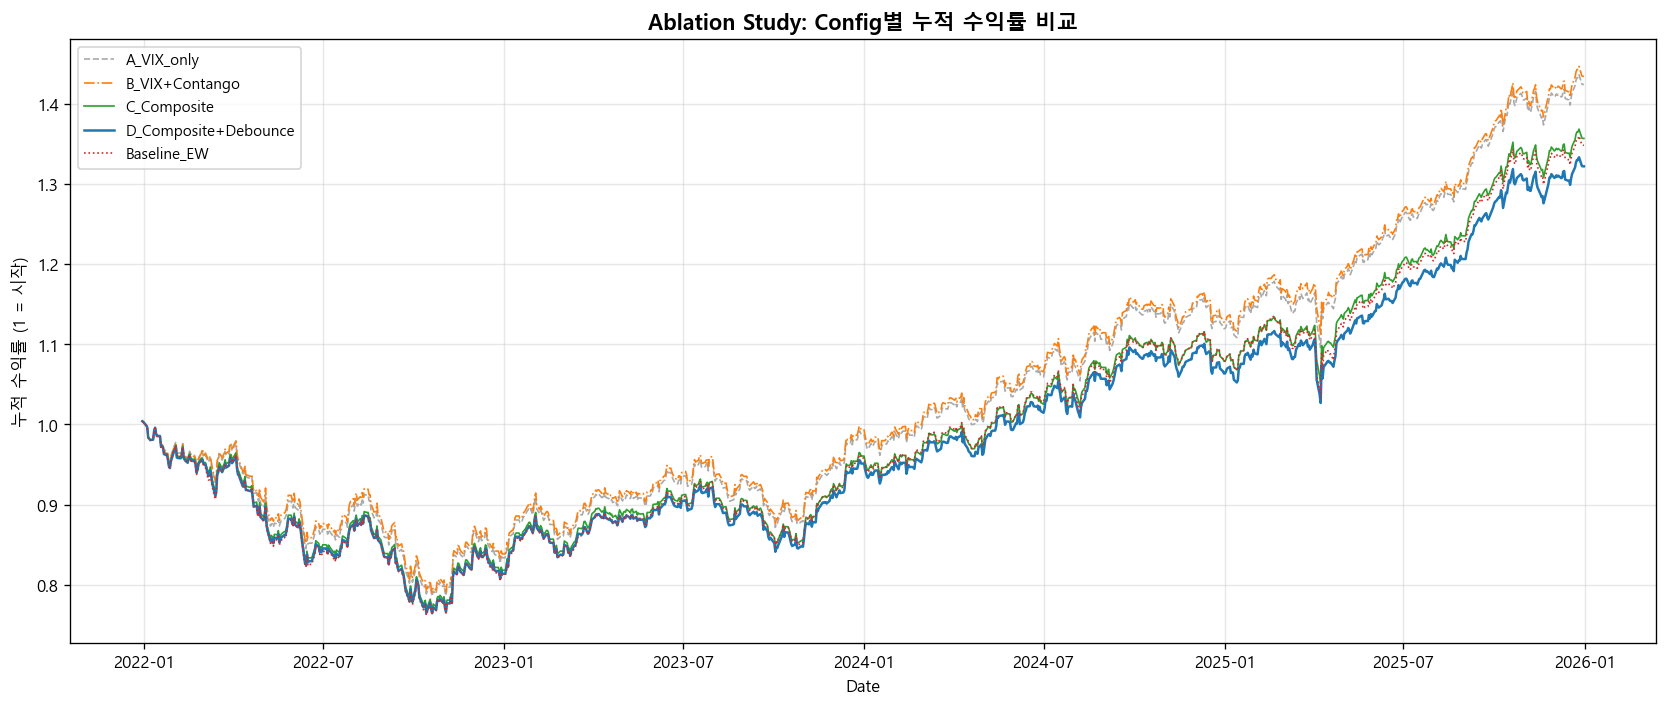

저장: images/ablation_01_cumulative.png


In [7]:
# ============================================================
# (1) 누적 수익률 비교
# ============================================================

cum_ret = (1 + df_results).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
colors = {'A_VIX_only': '#aaaaaa', 'B_VIX+Contango': '#ff7f0e',
          'C_Composite': '#2ca02c', 'D_Composite+Debounce': '#1f77b4',
          'Baseline_EW': '#d62728'}
styles = {'A_VIX_only': '--', 'B_VIX+Contango': '-.',
          'C_Composite': '-', 'D_Composite+Debounce': '-',
          'Baseline_EW': ':'}

for config in cum_ret.columns:
    ax.plot(cum_ret.index, cum_ret[config],
            color=colors.get(config, 'gray'),
            linestyle=styles.get(config, '-'),
            linewidth=1.5 if 'D_' in config else 1,
            label=config)

ax.set_title('Ablation Study: Config별 누적 수익률 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('누적 수익률 (1 = 시작)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'ablation_01_cumulative.png'), bbox_inches='tight')
plt.show()
print('저장: images/ablation_01_cumulative.png')

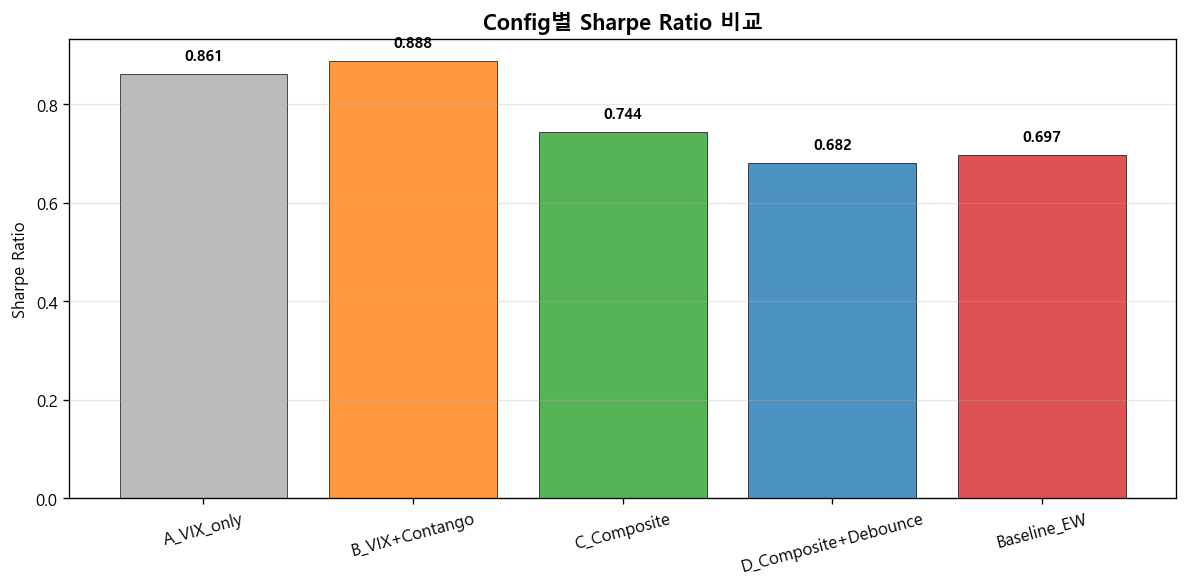

저장: images/ablation_02_sharpe.png


In [8]:
# ============================================================
# (2) Sharpe Ratio 막대 + Bootstrap CI
# ============================================================

# 각 Config의 Sharpe
sharpes = {}
for config in df_results.columns:
    r = df_results[config]
    sharpes[config] = r.mean() / r.std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 5))
configs = list(sharpes.keys())
vals = [sharpes[c] for c in configs]
bar_colors = [colors.get(c, 'gray') for c in configs]

bars = ax.bar(configs, vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 값 라벨
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Config별 Sharpe Ratio 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'ablation_02_sharpe.png'), bbox_inches='tight')
plt.show()
print('저장: images/ablation_02_sharpe.png')

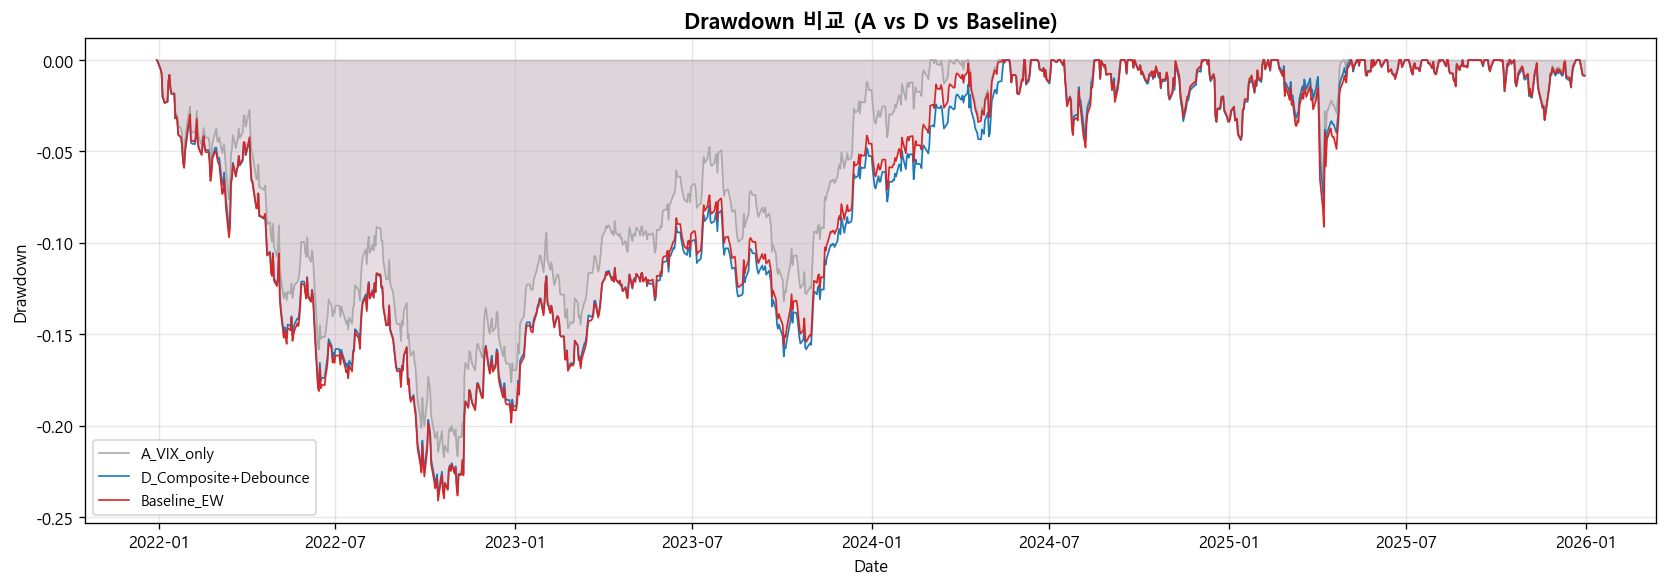

저장: images/ablation_03_drawdown.png


In [9]:
# ============================================================
# (3) Drawdown 비교
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

for config in ['A_VIX_only', 'D_Composite+Debounce', 'Baseline_EW']:
    cum = (1 + df_results[config]).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    ax.plot(dd.index, dd, color=colors[config], linewidth=1, label=config)
    ax.fill_between(dd.index, dd, 0, color=colors[config], alpha=0.1)

ax.set_title('Drawdown 비교 (A vs D vs Baseline)', fontsize=13, fontweight='bold')
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'ablation_03_drawdown.png'), bbox_inches='tight')
plt.show()
print('저장: images/ablation_03_drawdown.png')

In [10]:
# ============================================================
# (4) 최종 요약 테이블
# ============================================================

print('=' * 80)
print('               Ablation Study 최종 결과 요약')
print('=' * 80)
print()
print(df_metrics.to_string())
print()
print('--- Bootstrap Sharpe 차이 (vs Config A) ---')
print(df_boot.to_string(index=False))
print()

# 핵심 인사이트
print('=== 핵심 인사이트 ===')
print()

# Sharpe 최고/최저
sharpe_vals = {k: v for k, v in sharpes.items() if k != 'Baseline_EW'}
best_config = max(sharpe_vals, key=sharpe_vals.get)
print(f'1. 최고 Sharpe: {best_config} ({sharpes[best_config]:.3f})')
print(f'2. Baseline EW Sharpe: {sharpes["Baseline_EW"]:.3f}')
print(f'3. Config A (VIX-only) Sharpe: {sharpes["A_VIX_only"]:.3f}')
improvement = (sharpes[best_config] / sharpes['A_VIX_only'] - 1) * 100
print(f'4. 최고 Config의 A 대비 Sharpe 개선: {improvement:+.1f}%')

               Ablation Study 최종 결과 요약

                     연율 수익률  연율 변동성  Sharpe  Sortino      MDD  Calmar CVaR 99%
Config                                                                        
A_VIX_only            9.07%  10.54%   0.861    1.313  -21.72%   0.418  -0.0194
B_VIX+Contango        9.23%  10.39%   0.888    1.351  -21.26%   0.434  -0.0193
C_Composite           7.92%  10.65%   0.744    1.103  -23.43%   0.338  -0.0202
D_Composite+Debounce  7.30%  10.71%   0.682    0.999  -23.84%   0.306  -0.0209
Baseline_EW           7.83%  11.23%   0.697    1.024  -24.09%   0.325  -0.0223

--- Bootstrap Sharpe 차이 (vs Config A) ---
              Config     CI_lo    CI_med     CI_hi 유의
      B_VIX+Contango -0.035997  0.027566  0.095653 No
         C_Composite -0.202968 -0.115996 -0.032213 No
D_Composite+Debounce -0.283440 -0.178425 -0.081803 No

=== 핵심 인사이트 ===

1. 최고 Sharpe: B_VIX+Contango (0.888)
2. Baseline EW Sharpe: 0.697
3. Config A (VIX-only) Sharpe: 0.861
4. 최고 Config의 A 대비 Sharpe 개